# EN3160 Assignment 01

## Intensity Transformations and Neighborhood Filtering

---

**Name:** R.A.C.D. Ranawaka  
**Index Number:** 230526A  


---

### Assignment Objective

This assignment investigates fundamental image processing techniques involving
intensity transformations and neighborhood filtering. The experiments explore
how different image enhancement and filtering techniques affect image
characteristics and visual quality.

# 1. Intensity Transformation with Breakpoints

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

preferred_image_path = Path("data/input/emma.jpg")
fallback_image_paths = [
    Path("data/input/q1.jpeg"),
    Path("data/input/im01.png"),
    Path("data/input/shells.tif"),
]

image_path = preferred_image_path
if not image_path.exists():
    image_path = next(
        (path for path in fallback_image_paths if path.exists()),
        image_path
    )

im = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

if im is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

#### * Implementing the intensity transformation function

In [ ]:
def intensity_transform(im, breakpoints):
    
    breakpoints = np.asarray(breakpoints, dtype=np.float32)

    input_values = breakpoints[:, 0]
    output_values = breakpoints[:, 1]

    transformed = np.interp(
        im.astype(np.float32),
        input_values,
        output_values
    )

    transformed = np.clip(transformed, 0, 255)

    return transformed.astype(np.uint8)

#### * Different Breakpoint Configurations

In [ ]:
breakpoints_0 = np.array([
    [0,   0],
    [50,  50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])

breakpoints_1 = np.array([
    [0,   0],
    [50,  30],
    [50, 110],
    [150, 255],
    [150, 140],
    [255, 255]
])

breakpoints_2 = np.array([
    [0,   0],
    [50,  40],
    [50, 100],
    [150, 235],
    [150, 160],
    [255, 255]
])

breakpoints_3 = np.array([
    [0,   0],
    [50,  30],
    [50, 80],
    [150, 20],
    [150, 80],
    [255, 50]
])

breakpoint_configs = {
    "Configuration 0": breakpoints_0,
    "Configuration 1": breakpoints_1,
    "Configuration 2": breakpoints_2,
    "Configuration 3": breakpoints_3,
}

transformed_images = {
    name: intensity_transform(im, breakpoints)
    for name, breakpoints in breakpoint_configs.items()
}

#### * Comparison between original image and transformed image

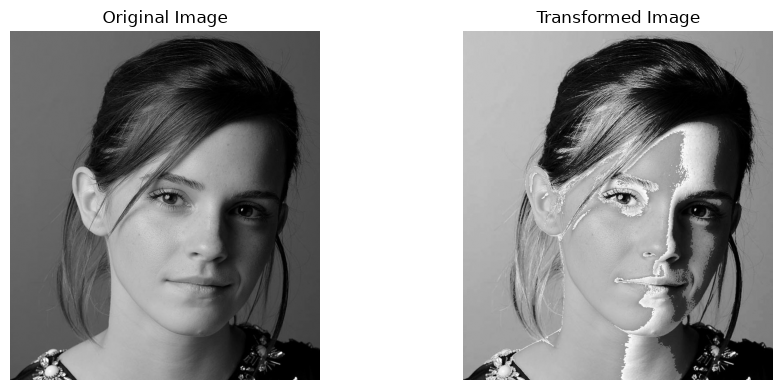

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(im, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(transformed, cmap="gray")
axes[1].set_title("Transformed Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### * Transformed Images and Histograms by Breakpoint Configuration

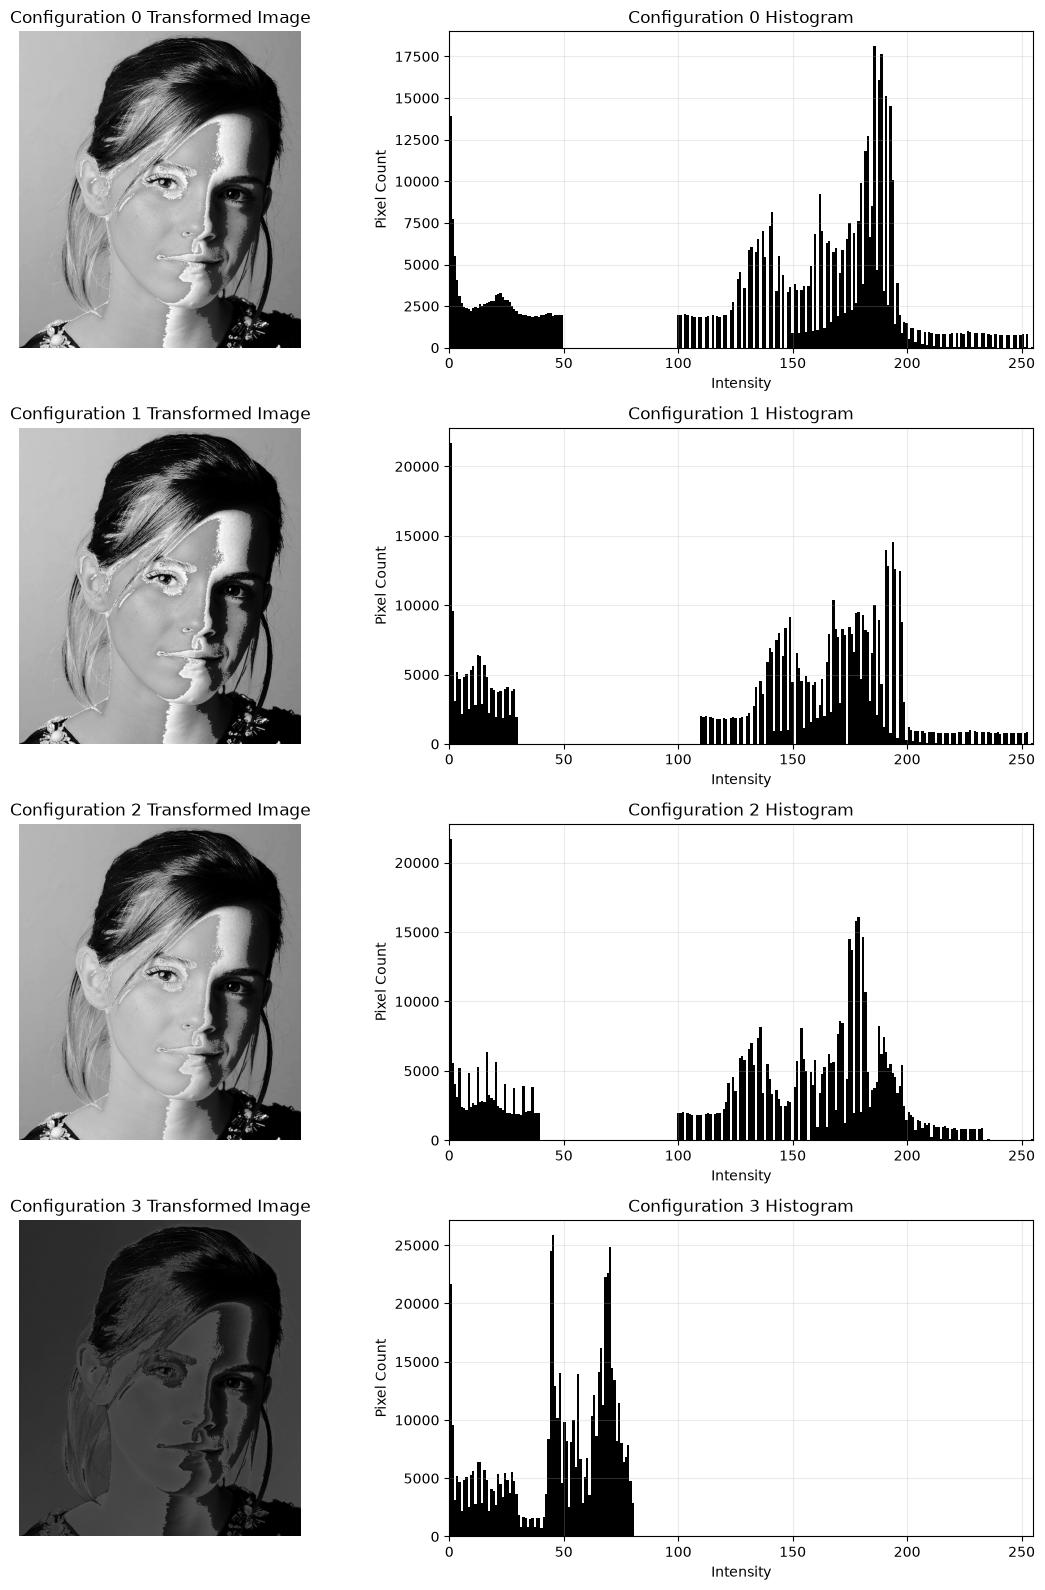

In [66]:
fig, axes = plt.subplots(
    len(transformed_images),
    2,
    figsize=(12, 4 * len(transformed_images))
)

for row, (name, transformed_image) in enumerate(transformed_images.items()):
    image_axis, histogram_axis = axes[row]

    image_axis.imshow(transformed_image, cmap="gray", vmin=0, vmax=255)
    image_axis.set_title(f"{name} Transformed Image")
    image_axis.axis("off")

    histogram_axis.hist(
        transformed_image.ravel(),
        bins=256,
        range=(0, 255),
        color="black"
    )
    histogram_axis.set_title(f"{name} Histogram")
    histogram_axis.set_xlabel("Intensity")
    histogram_axis.set_ylabel("Pixel Count")
    histogram_axis.set_xlim(0, 255)
    histogram_axis.grid(alpha=0.25)

plt.tight_layout()
plt.show()